## Pixel Length and Area Computation of Roads in Maps Using Morphological Operations
Aian Rosales

The purpose of this notebook is to determine pixel length and pixel area in all the roads in a given map. Various morphological operations are utilized to compute for this as best as possible.

I first call the libraries needed:

In [1]:
import numpy as np
from skimage.io import imshow

I then set up a structuring element that I will use as a "probe" to update pixels. It can be of any size and have a default structure that can be represented as a binary image. One pixel in the said element is is denoted as the origin, which is also often the central pixel of the symmetric structure. Translations of the element can be made anywhere in the image, with the origin as a reference point$^1$. This can then be used to either enlarge or contract a region, which we will discuss in detail later.

For this instance, I defined two types of structuring elements: a cross with the center pixels set to 1, and a disk object, 6 pixels across in size.

/home/msds/anaconda3/lib/python3.6/site-packages/skimage/io/_plugins/matplotlib_plugin.py:77: UserWarning: Low image data range; displaying image with stretched contrast.
  warn("Low image data range; displaying image with "


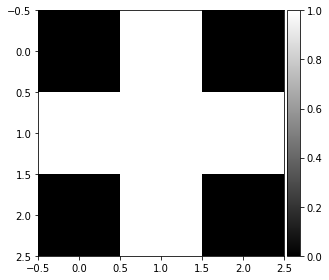

In [2]:
selem_circ = np.array([[0,1,0],
                     [1,1,1],
                     [0,1,0]])
imshow(selem_circ, cmap='gray');

/home/msds/anaconda3/lib/python3.6/site-packages/skimage/io/_plugins/matplotlib_plugin.py:77: UserWarning: Low image data range; displaying image with stretched contrast.
  warn("Low image data range; displaying image with "


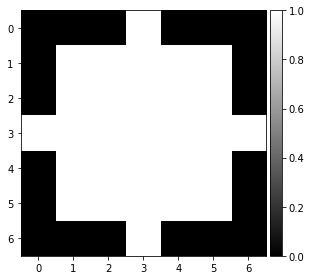

In [4]:
from skimage.morphology import disk

selem_disk3 = disk(3)
imshow(selem_disk3, cmap='gray');

I first take in an image of a map, then convert it to grayscale first; this is for the binarizing process later.

In [18]:
from skimage.io import imread
from skimage.color import rgb2gray

import matplotlib.pyplot as plt
%matplotlib inline

map_me = rgb2gray(imread('map2.png'))

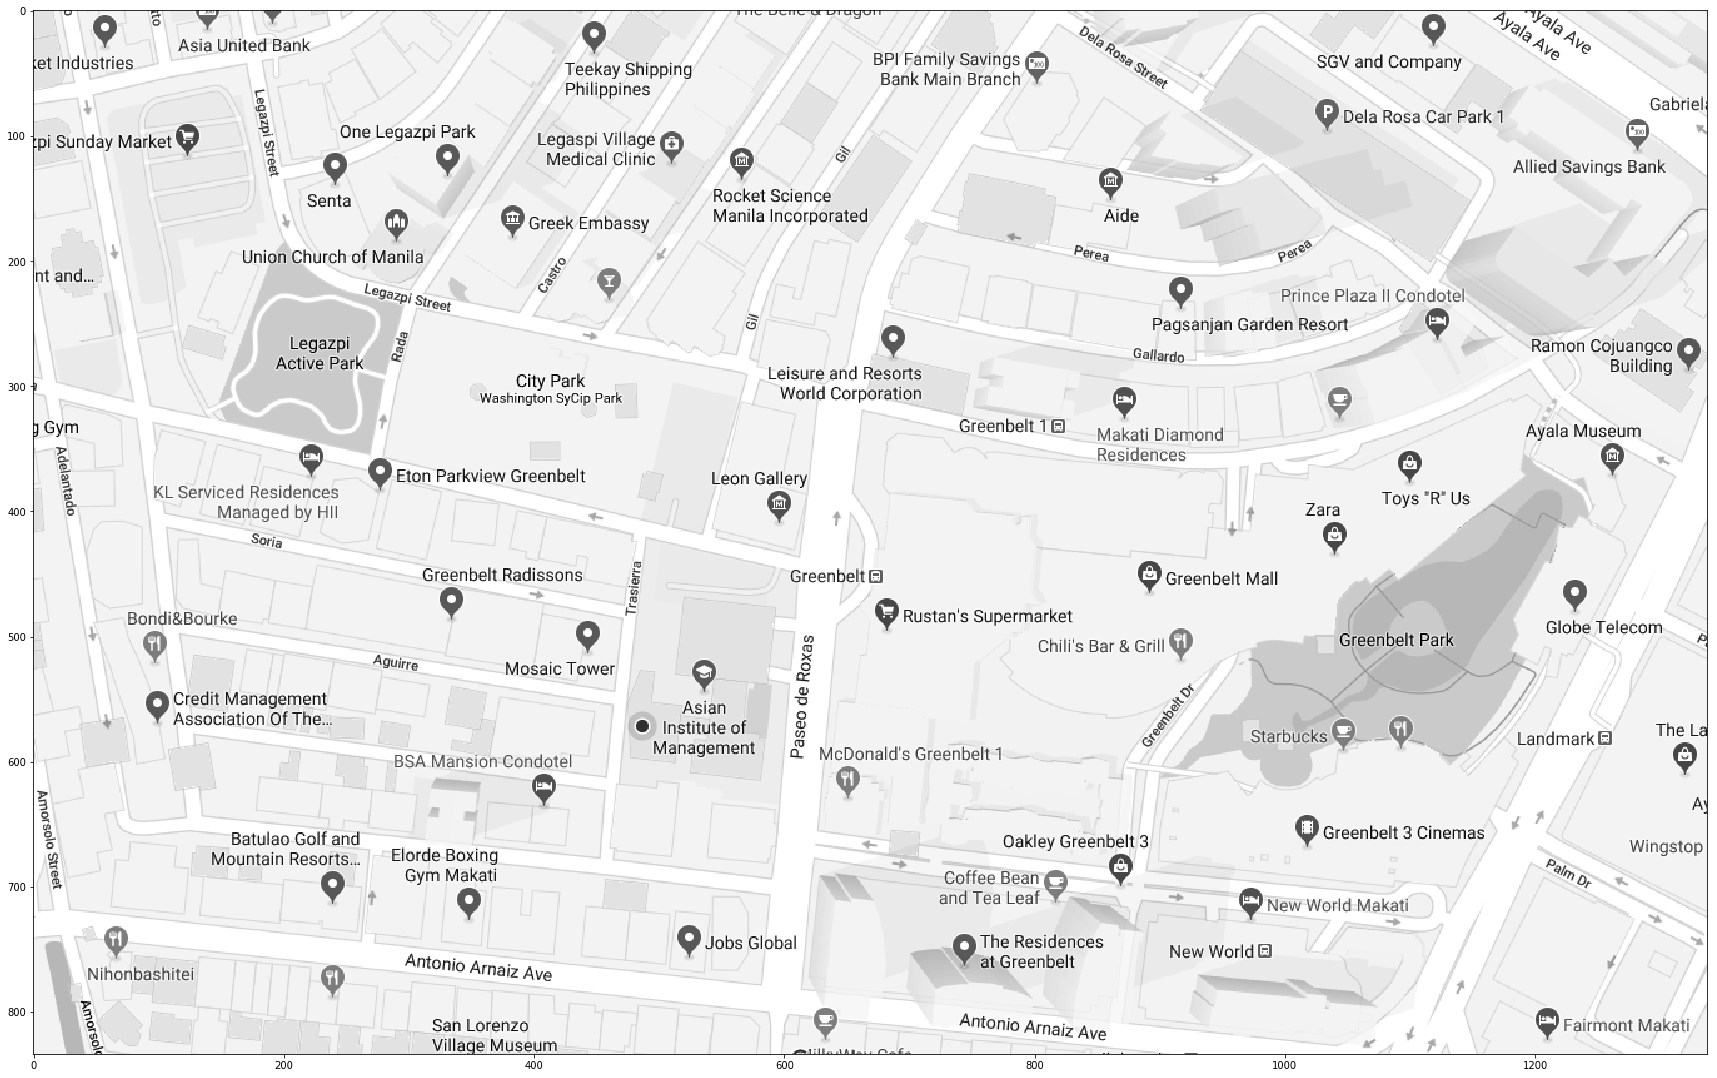

In [13]:
fig = plt.figure(figsize = (30,30))
ax = fig.add_subplot(111)
ax.imshow(map_me, cmap='gray')

plt.show()

I then proceeded with binarizing the image, which means converting the pixel values into integers. I used the astype(int) to do so.

/home/msds/anaconda3/lib/python3.6/site-packages/skimage/io/_plugins/matplotlib_plugin.py:77: UserWarning: Low image data range; displaying image with stretched contrast.
  warn("Low image data range; displaying image with "


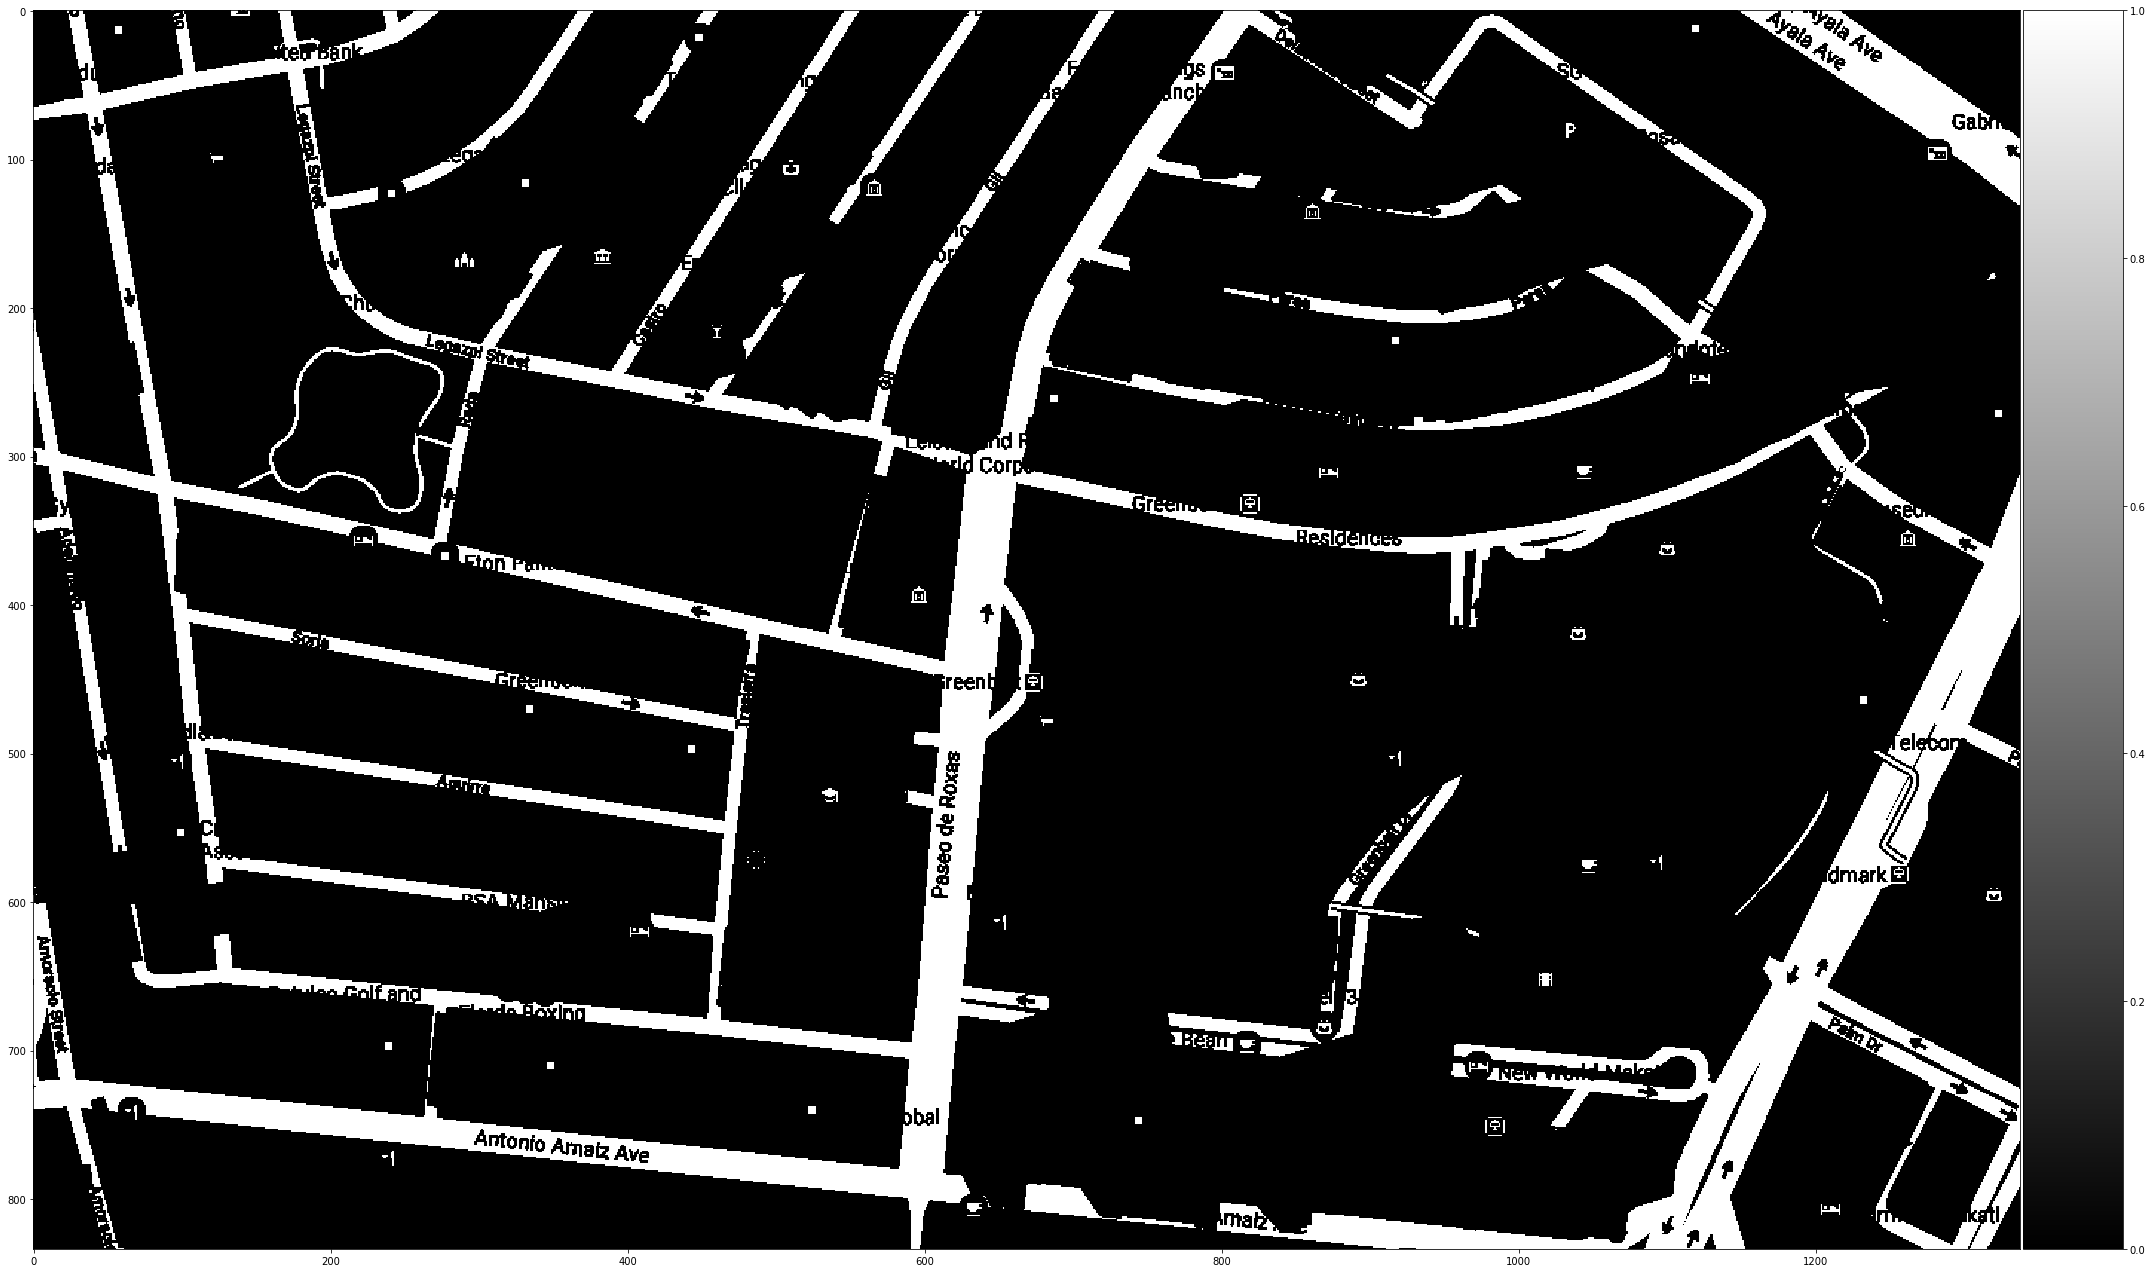

In [22]:
fig = plt.figure(figsize = (30,30)) 
map_me_bw = map_me.astype(int)
imshow(map_me_bw, cmap="gray")

In [24]:
map_me

array([[0.92941176, 0.92941176, 0.92941176, ..., 0.94454745, 0.94454745,
        0.94454745],
       [0.92941176, 0.92941176, 0.92941176, ..., 0.95487569, 0.94454745,
        0.94454745],
       [0.92941176, 0.92941176, 0.92941176, ..., 0.97164824, 0.96745882,
        0.95237569],
       ...,
       [0.96862745, 0.96862745, 0.96862745, ..., 0.96834471, 0.96834471,
        0.96834471],
       [0.96862745, 0.96862745, 0.96862745, ..., 0.96834471, 0.96834471,
        0.96834471],
       [0.96862745, 0.96862745, 0.96862745, ..., 0.96834471, 0.96834471,
        0.96834471]])

In [25]:
map_me_bw

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

To further reduce the number of black pixels in the streets (which is originally where the street names occluded the street pixels), I then experimented with various thresholds that should include pixels to be converted to white:

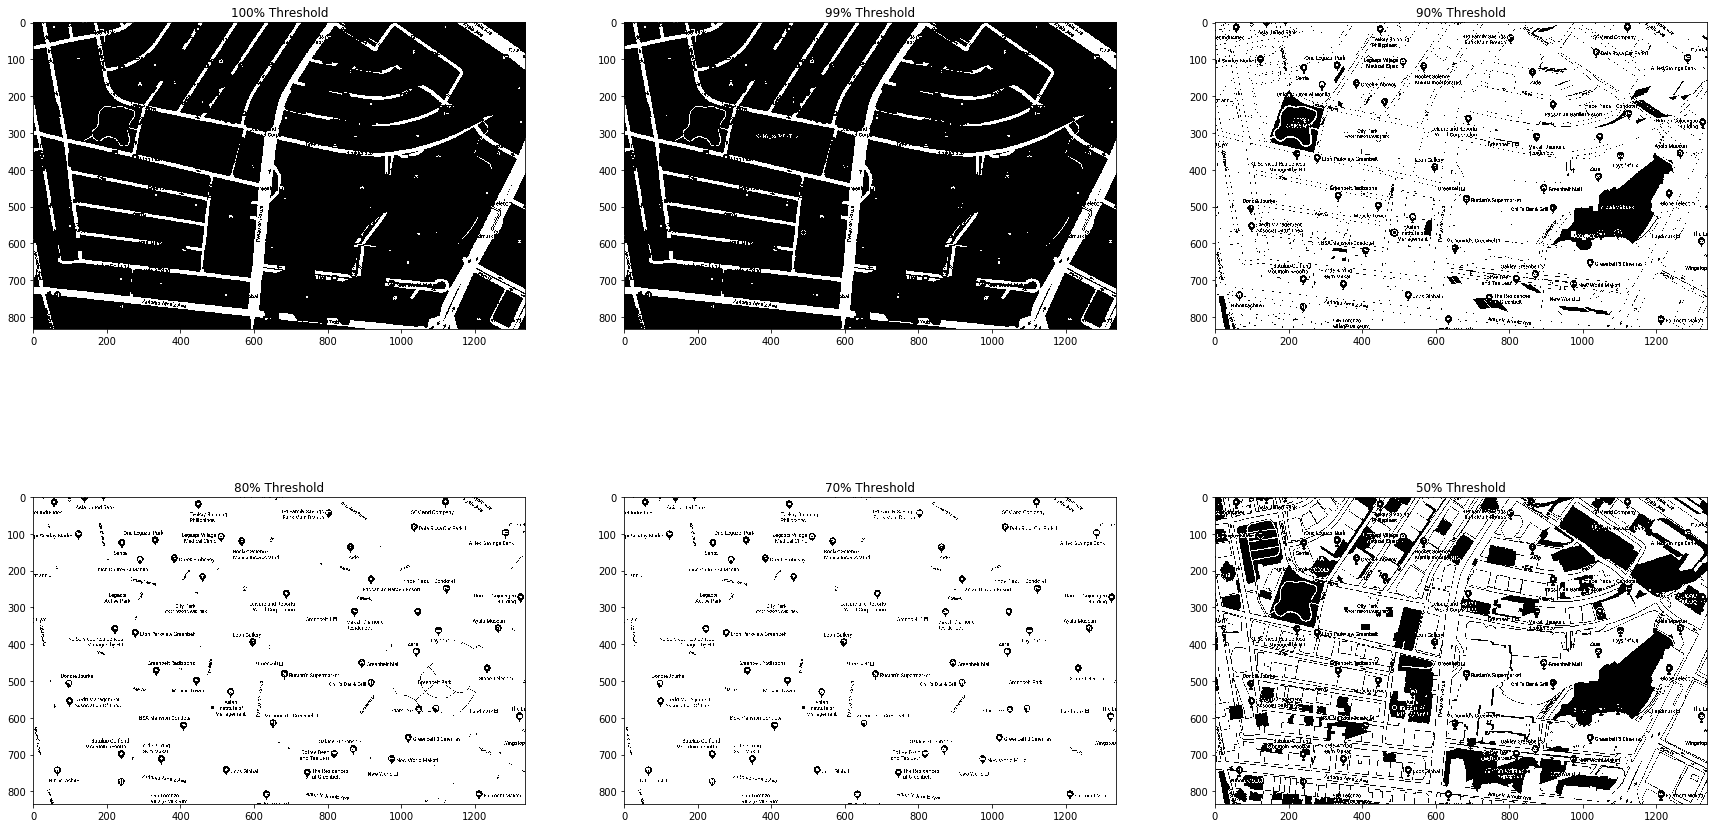

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(30,16))
ax[0,0].imshow(map_me.astype(int), cmap='gray')
ax[0,0].set_title('100% Threshold')
ax[0,1].imshow((map_me > 0.99).astype(int), cmap='gray')
ax[0,1].set_title('99% Threshold')
ax[0,2].imshow((map_me > 0.90).astype(int), cmap='gray')
ax[0,2].set_title('90% Threshold')
ax[1,0].imshow((map_me > 0.80).astype(int), cmap='gray')
ax[1,0].set_title('80% Threshold')
ax[1,1].imshow((map_me > 0.70).astype(int), cmap='gray')
ax[1,1].set_title('70% Threshold')
ax[1,2].imshow((map_me > 0.95).astype(int), cmap='gray')
ax[1,2].set_title('50% Threshold');

Based on the above diagrams, I eventually settled with 99% threshold as it demarcated road lines in the map more clearly than the other thresholds, and removed many of the road names that turned many parts of the roads to black.

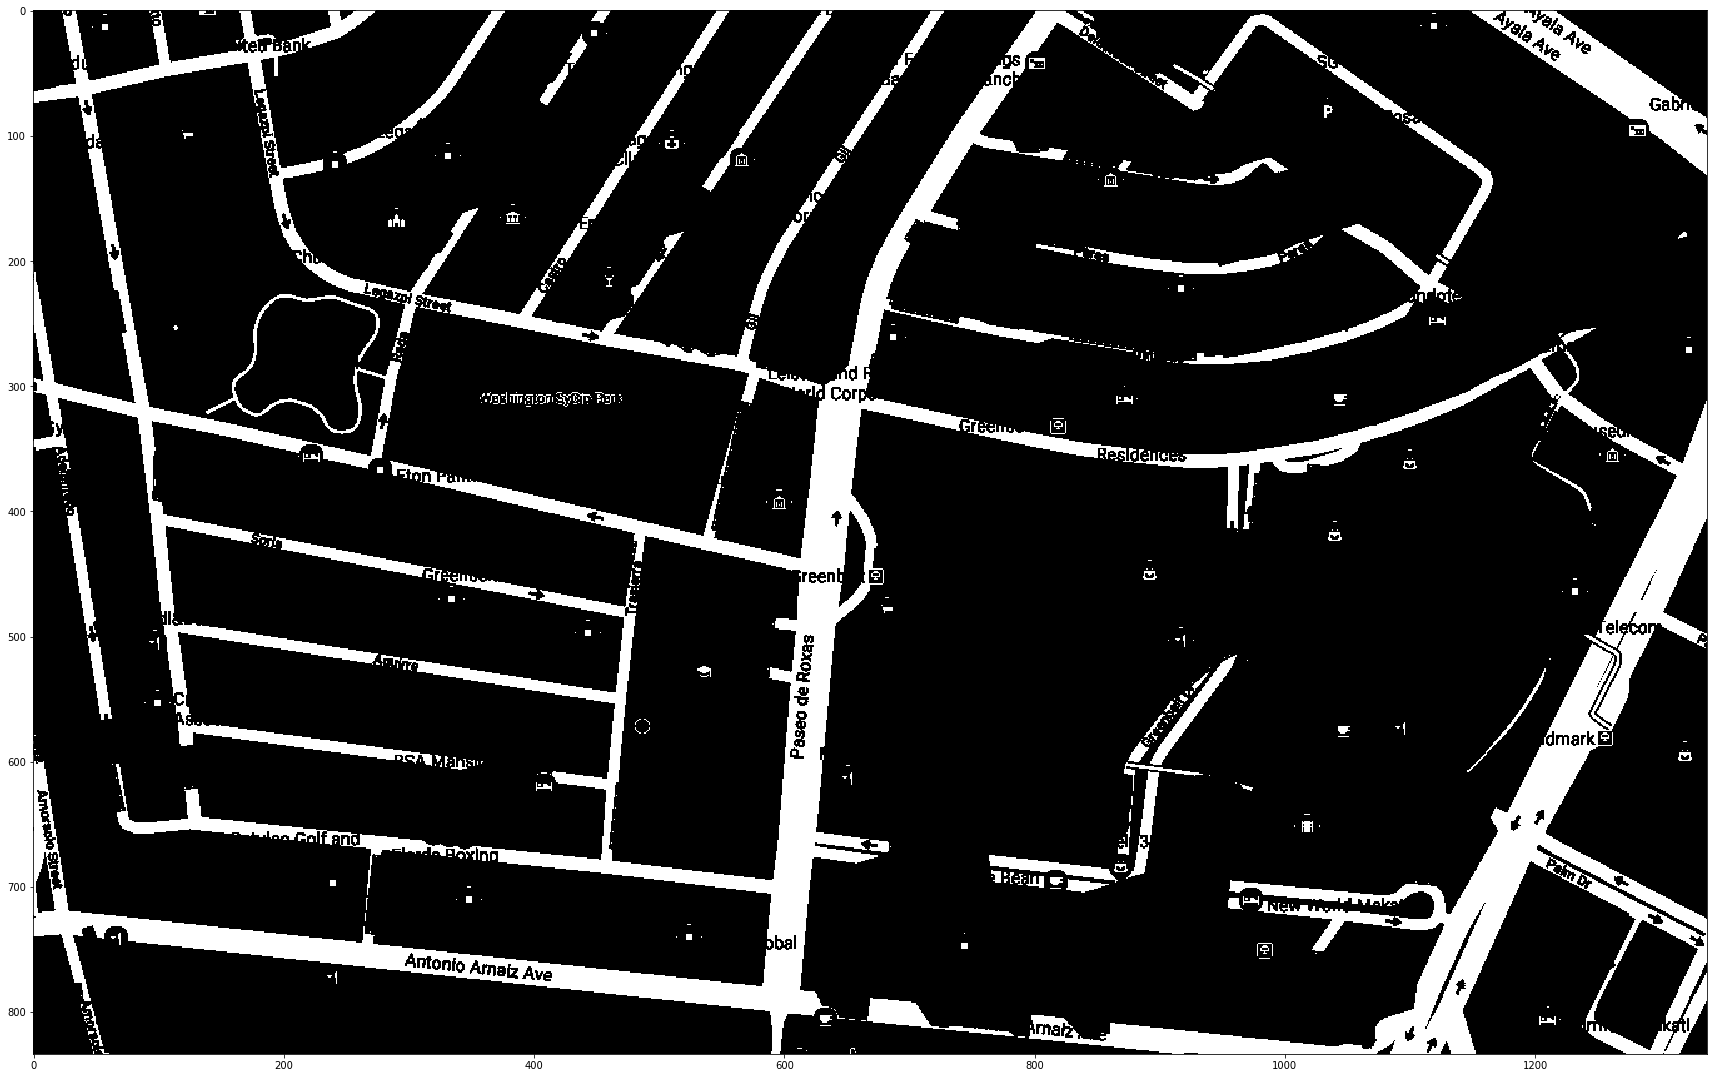

In [36]:
map_me_bw = (map_me > 0.99).astype(int)

fig = plt.figure(figsize = (30,30)) 
ax = fig.add_subplot(111)
ax.imshow(map_me_bw, cmap='gray')

plt.show()

I now turned to morphological operations to try to perform the following:
- close down gaps in the road pixels that the street names left when we binarized the image
- close down gaps in the road pixels that other gaps, such as depictions of large buildings, have occluded as well
- further widen or polish edges of the roads, but not too much as to make them look thicker, skewing the pixel area measurements
- measure the pixel length of the roads.

Given this, the following operations will be used (these functions are available in the skimage library):
- *erosion*, which sets the value of a pixel to its minimum value selected by the structuring element; it basically removes pixels from the edges
- *dilation*, which sets the pixel value to its maximum value selected by the structuring element.
- *closing*, which dilates then erodes pixels; it closes the gaps for dominant black regions
- *opening*, which erodes then dilates pixels; it meanwhile closes the gaps for dominant white regions
- *skeletonize*, which represents binary objects as 1-pixel wide images.

I will be using the first 4 operations to close down various gaps in the images. Skeletonize will be used to measure pixel length.

First, I closed the gaps listed above, by using these functions one after the other. I tried various combination of techniques as well, to see what would most accurately pattern the road pixel sizes in the original picture. 

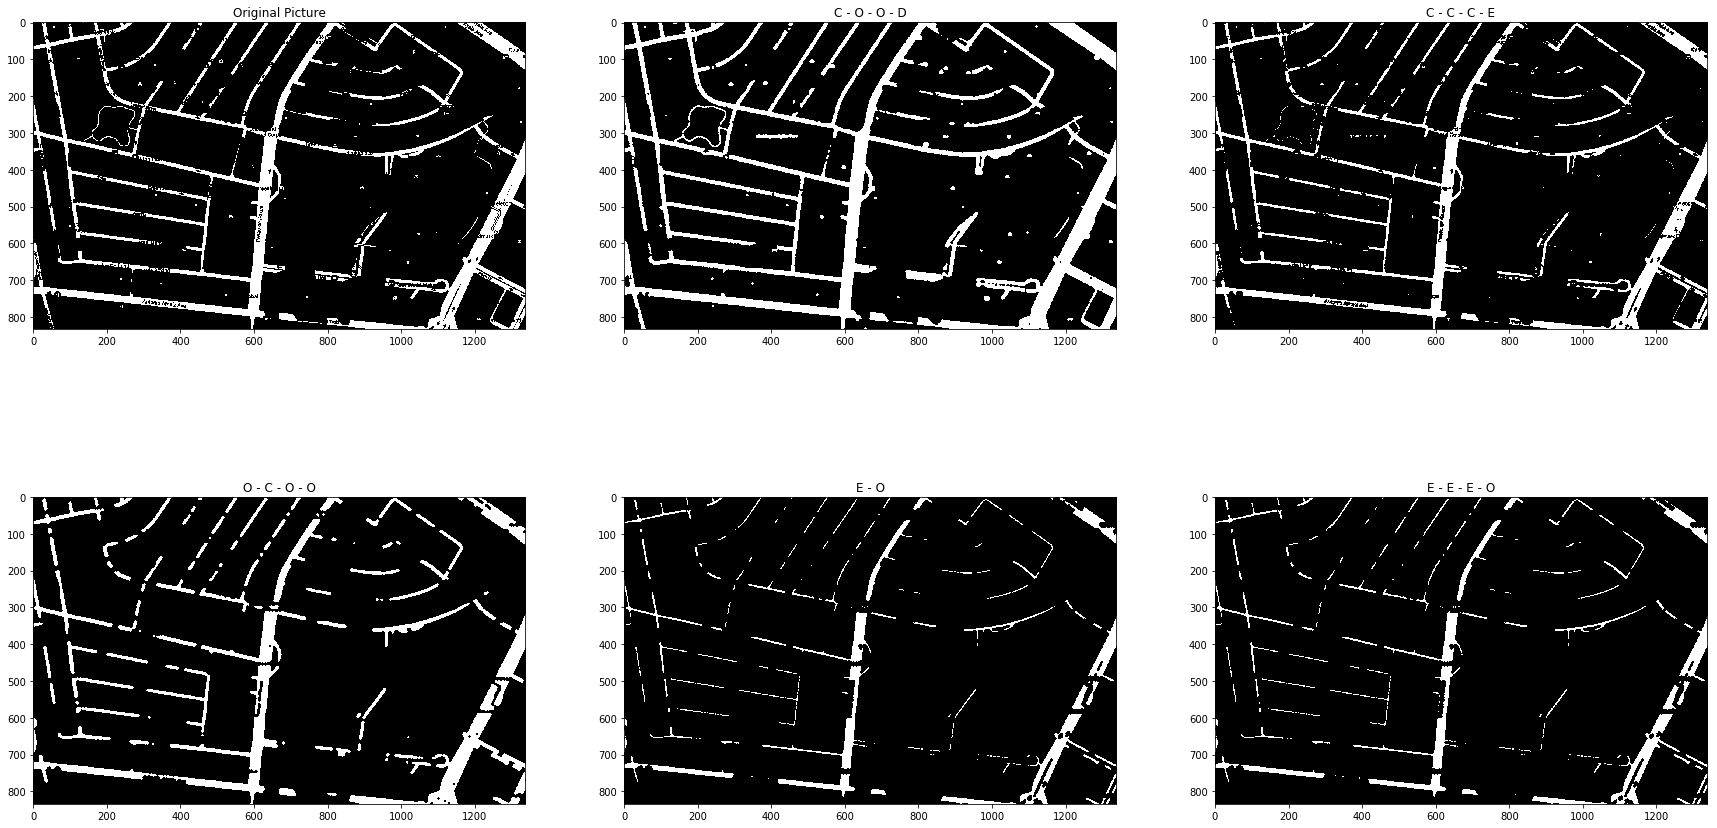

In [42]:
fig, ax = plt.subplots(2, 3, figsize=(30,16))
ax[0,0].imshow(map_me.astype(int), cmap='gray')
ax[0,0].set_title('Original Picture')
ax[0,1].imshow(dilation(opening(opening(closing(map_me_bw, selem_disk3), selem_circ))), cmap='gray')
ax[0,1].set_title('C - O - O - D')
ax[0,2].imshow(erosion(closing(closing(closing(map_me_bw)))), cmap='gray')
ax[0,2].set_title('C - C - C - E')
ax[1,0].imshow(opening(opening(closing(opening(map_me_bw, selem_disk3), selem_disk3), selem_circ)), cmap='gray')
ax[1,0].set_title('O - C - O - O')
ax[1,1].imshow(opening(erosion(map_me_bw, selem_disk3), selem_circ), cmap='gray')
ax[1,1].set_title('E - O')
ax[1,2].imshow(opening(erosion(erosion(erosion(map_me_bw)))), cmap='gray')
ax[1,2].set_title('E - E - E - O');

I eventually chose the C - O - O - D method, with the following steps:

1. closing (using disk(3) as a structuring element)
2. opening (using the selem_circ as a structuring element)
3. opening (default structuring element used)
4. opening (default structuring element used)
5. dilation (default structuring element used).

I will be using this to measure road pixel area.

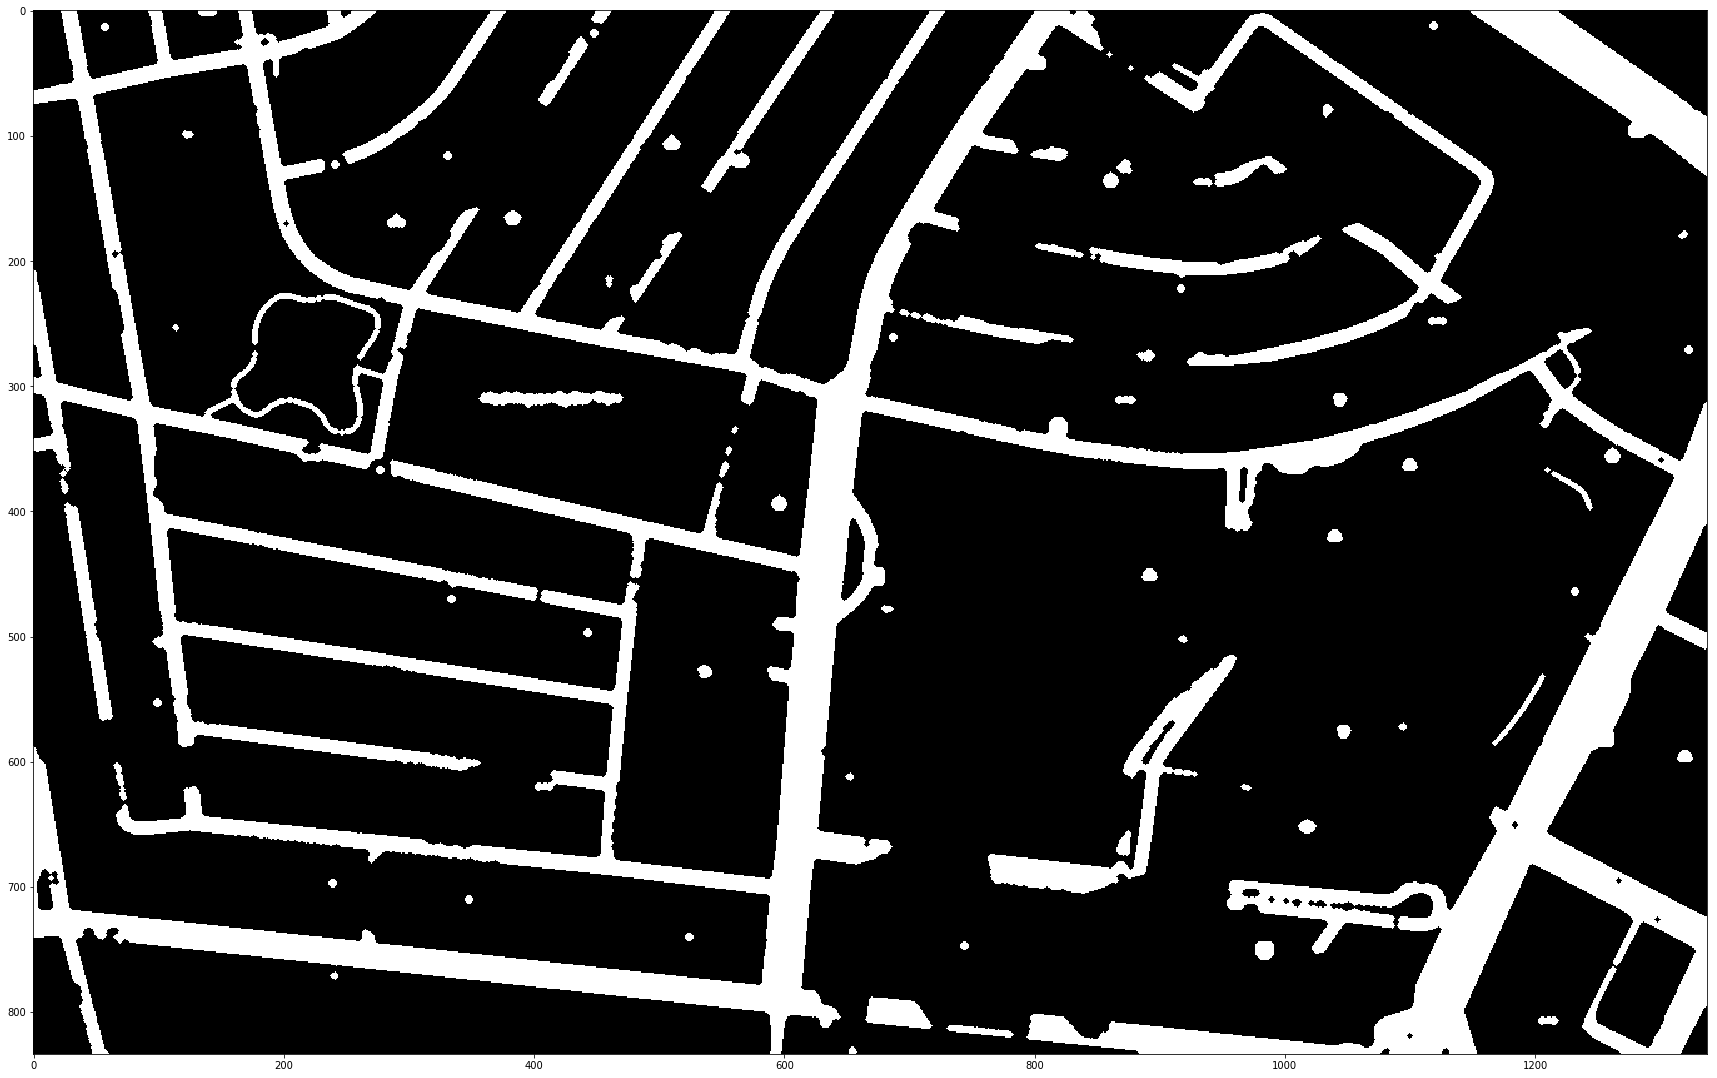

In [44]:
from skimage.morphology import dilation, erosion, opening, closing, skeletonize

new_img = dilation(opening(opening(closing(map_me_bw, selem_disk3), selem_circ)))
fig = plt.figure(figsize = (30,30)) 
ax = fig.add_subplot(111)
ax.imshow(new_img, cmap='gray')
plt.show()

I then got the pixel sum by getting the sum of all the 1's in the binarized morphed image:

In [45]:
# pixel sum of all the roads
new_img.sum()

190944

To get the pixel length, it would be best to try to bridge first all the gaps in the roads before we perform the skeletonize function. It should be ok for the roads to get really thick, since it's important for the roads to be connected at least.

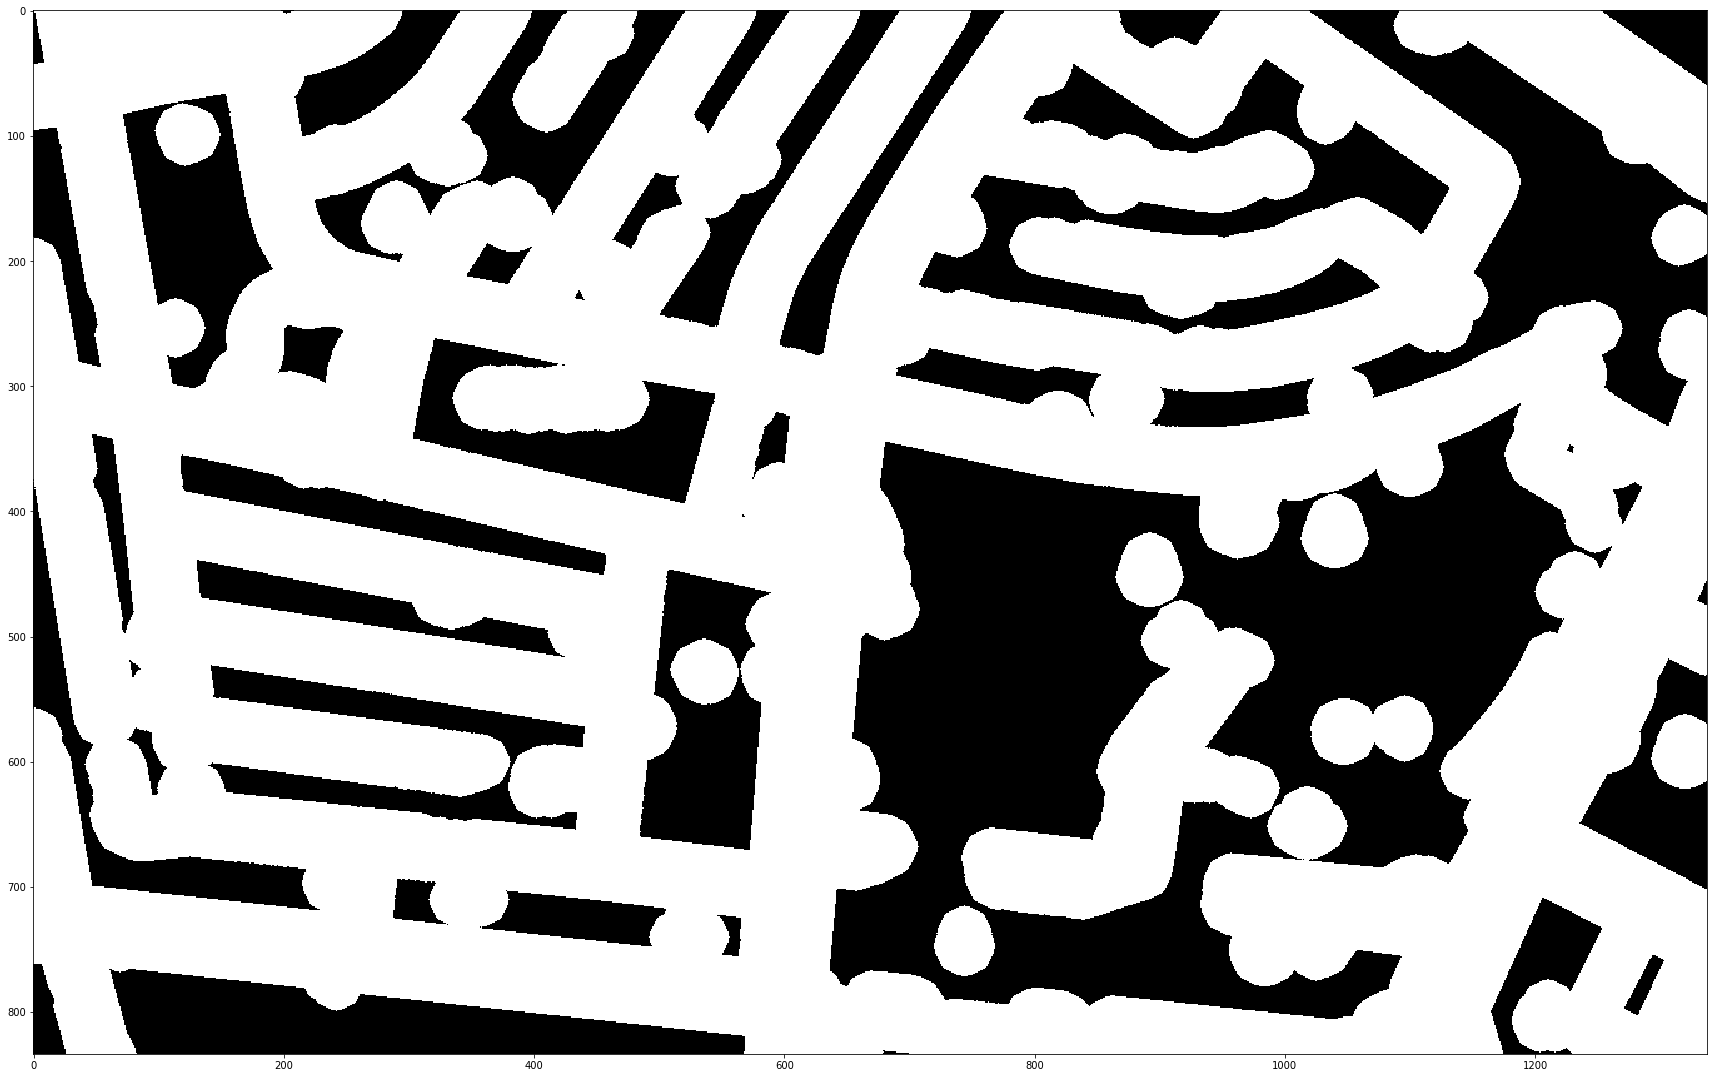

In [70]:
selem_disk10 = disk(10)

new_img1 = dilation(dilation(dilation(dilation(dilation(map_me_bw, selem_disk3), selem_disk3), selem_disk3), selem_disk3), selem_disk10)
fig = plt.figure(figsize = (30,30)) 
ax = fig.add_subplot(111)
ax.imshow(new_img1, cmap='gray')
plt.show()

We then reduce the roads to just 1 pixel wide using the skeletonize function:

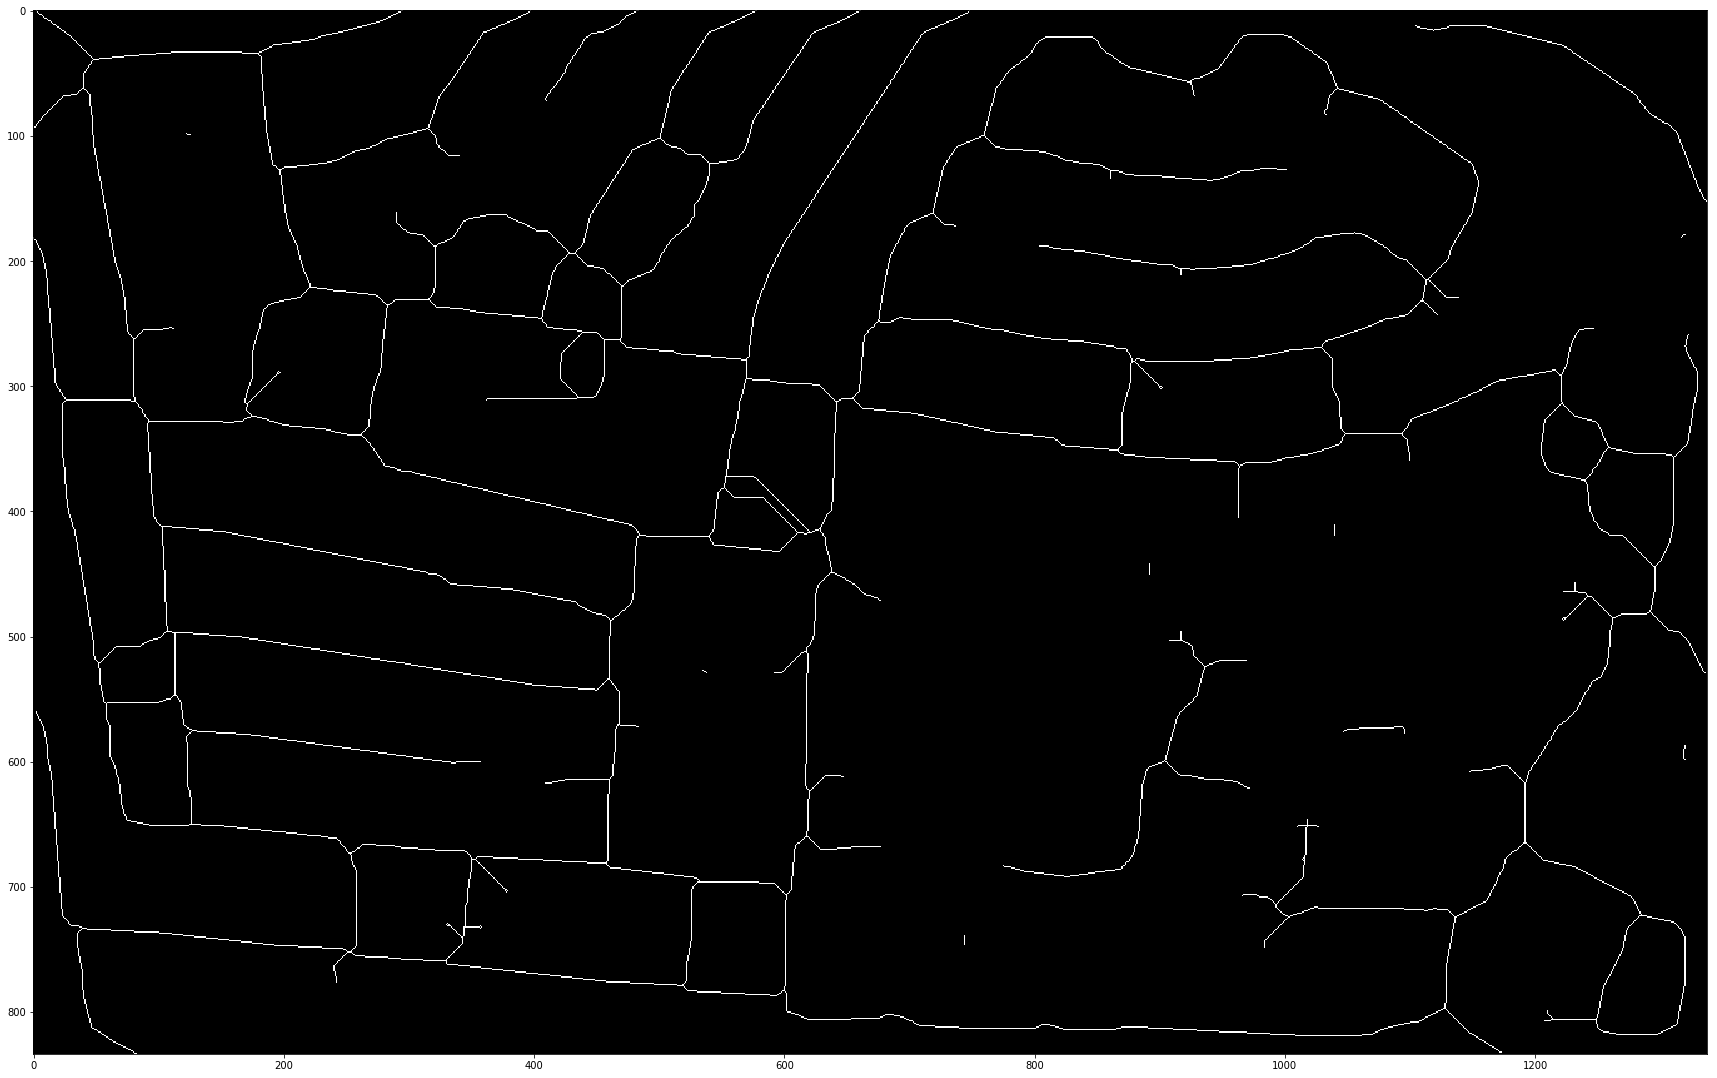

In [72]:
new_img2 = skeletonize(new_img1)
fig = plt.figure(figsize = (30,30)) 
ax = fig.add_subplot(111)
ax.imshow(new_img2, cmap='gray')
plt.show()

We then use the "skeletonized" image to get the pixel length.

In [74]:
# pixel length
new_img2.sum()

14459

The main challenge in getting the pixel areas and lengths are the non-road artifacts in the map, such as landmarks, street names and buildings. As mentioned earlier, these occlude the roads, which then hampers with isolating the road network itself. This can be remedied by using a map that does away with most of these artifacts, though these are rare nowadays due to the pervasiveness of geo-location tagging in social media.

Another challenge was in identifying the functions and structure elements that should be used to enhance the roads themselves, A right balance should be struck to avoid losing too many details and to highlight too much of it. I did this with a lot of trial-and-errors, and the results could be a little too subjective as well. In the end, I just stuck with an eyeball approximation on the best way to isolate the road network.

## References
References
1. Chapter 3: Binary Image Analysis [Internet]. Courses.cs.washington.edu. 2000 [cited 5 November 2018]. Available from: https://courses.cs.washington.edu/courses/cse576/book/ch3.pdf
2. Alis C., Morphological Operations. 2018.